# Predicting Credit Card Default Payments

### Phase 2 Report — Predictive Modelling

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Group: Group 35**

| No. | Student Name | Student ID |
|-----|-------------|------------|
| 1   | Nikhila M   |  S4087528  |
| 2   | Aiswarya Sudhir | S4084978 |
| 3   | Rajan Vipulkumar Patel | S4113210 |

## Table of Contents

1. Introduction
   - 1.1 Phase 1 Summary
   - 1.2 Report Overview
   - 1.3 Overview of Methodology
2. Predictive Modelling
   - 2.1 Feature Selection
   - 2.2 Model Fitting & Tuning
     - 2.2.1 Logistic Regression
     - 2.2.2 Decision Tree
     - 2.2.3 Random Forest
     - 2.2.4 Naive Bayes
     - 2.2.5 MLP Neural Network
     - 2.2.6 Declaration of Generative AI Use
   - 2.3 Model Comparison
3. Critique & Limitations
4. Summary & Conclusions
   - 4.1 Project Summary
   - 4.2 Summary of Findings
   - 4.3 Conclusions
5. References

## 1. Introduction

### 1.1 Phase 1 Summary

Phase 1 of this project established the data foundation for predictive modelling by sourcing, cleaning, and exploring the UCI Default of Credit Card Clients Dataset. The dataset contains records of 30,000 credit card clients from a Taiwanese bank, spanning April to September 2005, with the objective of predicting whether a client will default on their payment in October 2005.

**Data Cleaning and Preprocessing**

Preprocessing began by removing the `ID` column, which carried no predictive information. A check for missing values confirmed that none were present across all 24 remaining features. 35 duplicate rows were identified, visually plotted, and removed; reducing this dataset to 29,965 observations. Upon examining categorical values, here's the results: EDUCATION contained values 0, 5, and 6, and MARRIAGE contained value 0, none of which appear in the dataset documentation. Rather than reassigning these to an existing category, the affected rows ( 399 in total) were removed entirely to preserve the integrity of the legitimate category labels. All categorical features were recoded with descriptive string labels for readability. Age values were realistic (range: 21–79 years), and negative bill amounts were valid overpayment entries and retained. Outliers were detected across all financial columns using the 1.5×IQR method and retained without modification, as they represent genuine financial behaviour that may carry predictive signal. The final cleaned dataset contains approximately 29,566 observations.

**Phase 1 corrections applied for phase 2:**

Based on the phase1's feedback, two corrections were made to the Phase 1 preprocessing before carrying data forward into Phase 2:

1. **Removal of invalid categorical rows instead of remapping:** In the original phase 1 submission, rows with undocumented EDUCATION values (0, 5, 6) and undocumented MARRIAGE values (0) were incorrectly remapped into the existing 'Others' category. This affects the integrity of Others by merging genuinely unknown observations into a defined class. In the corrected pipeline, all **399 such rows are removed entirely**, as their true category membership is unknown and cannot be reliably inferred.

2. **Outlier capping removed:**  In the original Phase 1 submission, financial columns (LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6) were capped at the 1.5 × IQR fences. This was flagged as problematic because extreme financial values are likely genuine observations. For example, some clients genuinely hold very high credit limits or make unusually large one-off payments in a single month. Capping these values artificially compresses the distribution and destroys real variation that may carry important predictive signal, particularly for identifying high-risk or high-value clients. The corrected version detects and reports outliers using the 1.5 × IQR method and visualises them via boxplots, but makes no modifications to the data. All original values are kept in their exact form in the dataset. For distance-sensitive models such as KNN and Logistic Regression, StandardScaler is applied within a Pipeline during Phase 2 modelling, which normalises feature scales without altering or discarding any data points.

After applying these corrections, the cleaned dataset contains **29,566 observations** and **23 descriptive features** (plus the target), which forms the input to all Phase 2 modelling.

**Data Exploration and Visualisation**

12 visualisations were produced spanning one-variable, two-variable, and three-variable analyses. The key findings are as follows:

- The dataset is class-imbalanced: approximately 22.1% of clients defaulted, with 77.9% not defaulting. Addressing this imbalance is essential for reliable modelling.
- Recent repayment status (`PAY_0`) emerged as the strongest individual predictor of default. Clients with payment delays of one or more months were substantially more likely to default the following month.
- Credit limit (`LIMIT_BAL`) showed meaningful separation between defaulters (median ~NT\$100,000) and non-defaulters (median ~NT\$150,000).
- Consecutive bill amount columns (`BILL_AMT1`–`BILL_AMT6`) are highly correlated (r ≈ 0.95), indicating multicollinearity that must be managed during feature selection.
- Demographic features such as age and education showed weaker associations with default compared with behavioural features such as repayment status and payment amounts.
- Payment amount variables (`PAY_AMT1`–`PAY_AMT6`) exhibited a consistent pattern: non-defaulting clients make higher payments across all six months.

**Exploratory findings from Phase 1 that guide Phase 2:**

These Phase 1 findings shaped four key methodological decisions in Phase 2.

- **Feature prioritisation:** Because repayment status (`PAY_0`–`PAY_6`) and payment amount features showed the strongest associations with default in the Phase 1 EDA, they were expected to dominate the feature rankings and form the core of the final feature set. Section 2.1 confirms this using both `SelectKBest` (`f_classif`) and Random Forest feature importance.

- **Multicollinearity handling:** The high inter-correlation among the bill amount columns (`BILL_AMT1`–`BILL_AMT6`, r ≈ 0.95) directly motivated the use of a second, multivariate feature selection method. `f_classif` evaluates each `BILL_AMT` column independently and would retain all six, whereas Random Forest importance evaluates features jointly and discounts redundant ones by resolving the multicollinearity.

- **Choice of evaluation metric:** Because the dataset is class-imbalanced (~22% defaulters), **AUC-ROC** was chosen as the primary metric for both tuning and model comparison. AUC-ROC measures the model's ability to rank defaulters above non-defaulters across all thresholds and is unaffected by class proportions. Accuracy is deliberately excluded, since a trivial classifier predicting "no default" would already score ~78%.

- **Class imbalance correction:** Class imbalance is addressed at the algorithm level. `class_weight='balanced'` is applied to Logistic Regression, Decision Tree, and Random Forest. Gaussian Naive Bayes uses `priors=[0.5, 0.5]` as the equivalent correction. `MLPClassifier` supports neither parameter; this limitation is discussed in Critique & Limitations. MLP is included as the fifth algorithm because the Phase 1 literature review identified neural networks as the performance frontier for this dataset.

### 1.2 Report Overview

This Phase 2 report documents the full predictive modelling pipeline applied to the cleaned dataset produced in Phase 1, from feature selection through to model comparison and critique.

The report starts with this Introduction (Section 1), which recaps the Phase 1 work, describes the structure of the report, and provides a detailed account of the modelling methodology before any results are presented.

Section 2 (Predictive Modelling) is the core of the report and is divided into three parts. The first part, Feature Selection (Section 2.1), applies two complementary methods: univariate statistical scoring and tree-based feature importance, to identify the most informative features from the cleaned dataset. Supporting visualisations are included to justify the final feature set used for modelling. The second part, Model Fitting and Tuning (Section 2.2), covers all five machine learning algorithms individually. For each algorithm, the hyperparameter search space is defined, a grid search with 10-fold cross-validation is conducted, and the results of the tuning process are shown through at least one diagnostic plot. The best configuration identified for each algorithm is then used to report performance on the held-out test set. A Declaration of Generative AI use clearly stating how AI tools were used in this work and reflecting on their impact. The third part, Model Comparison (Section 2.3), draws the 10-fold cross-validated AUC-ROC scores from all five models and applies paired t-tests to determine whether the observed differences in performance are statistically significant.

Section 3 (Critique and Limitations) provides an honest and detailed reflection on the strengths and weaknesses of the approach taken in both phases, including methodological trade-offs, dataset constraints, and areas where the work could be extended.

Section 4 (Summary and Conclusions) ends the report with three subsections: a comprehensive project summary covering both phases, a summary of the key findings, and conclusions drawn with reference to the original goals and objectives established in Phase 1.

### 1.3 Overview of Methodology

This section provides a complete account of the predictive modelling methodology applied in Phase 2. All modelling is performed using Python with scikit-learn library.

**Data Preparation for Modelling**

Phase 2 loads `UCI_Credit_Card_cleaned.csv`, which was produced and saved at the end of Phase 1. This file contains the fully cleaned dataset with the ID column removed, duplicate rows dropped, and rows with undocumented category values in EDUCATION (0, 5, 6) and MARRIAGE (0) removed and saved at the point before string relabeling was applied. All features are therefore retained as integer codes, which is the format required by scikit-learn algorithms. No further cleaning is needed. The six repayment status columns (`PAY_0`, `PAY_2`–`PAY_6`) are treated as ordinal integers. The three categorical demographic features (SEX, EDUCATION, MARRIAGE) are also retained as integer codes, reflecting their ordinal or nominal structure in a form suitable for tree-based and linear models.

**Train/Test Split**

The cleaned dataset is split into a training set (80%) and a held-out test set (20%) using a stratified split to preserve the class ratio in both subsets. The random state is fixed for reproducibility. The test set is not used during feature selection or hyperparameter tuning as it is evaluated for final performance evaluation of each model.

**Feature Selection**

Two complementary feature selection methods are applied to the training set only, to avoid data leakage:

1. **Univariate statistical scoring** using `SelectKBest` with the `f_classif` scoring function (ANOVA F-test), which measures the strength of association between each individual feature and the binary target variable.
2. **Tree-based feature importance** using a Random Forest classifier fitted on the training set, which captures non-linear relationships and feature interactions that univariate methods may miss.

The scores and importances from both methods are visualised as bar charts. A final feature set is selected based on the agreement between both methods, prioritising features that rank highly in both. This approach reduces dimensionality while retaining the most informative signal for modelling.

**Algorithms**

Five machine learning algorithms are evaluated, each imported from a different scikit-learn submodule to ensure methodological diversity:

1. **Logistic Regression** (`sklearn.linear_model`): a linear probabilistic classifier that serves as the interpretable baseline. Its coefficient outputs allow direct inspection of feature influence on default probability.
2. **Decision Tree** (`sklearn.tree`): a non-linear, rule-based classifier that partitions the feature space through recursive splitting. It is fully interpretable and captures threshold-based relationships in repayment and payment variables.
3. **Random Forest** (`sklearn.ensemble`): an ensemble of decision trees that reduces variance through bootstrap aggregation. It is robust to outliers and provides reliable feature importance estimates.
4. **Gaussian Naive Bayes** (`sklearn.naive_bayes`): a probabilistic classifier based on Bayes' theorem with a Gaussian likelihood assumption. It is computationally efficient and provides a probability-based alternative to the discriminative models above.
5. **MLP Neural Network** (`sklearn.neural_network`): a multi-layer perceptron that can learn complex non-linear relationships between features. Its inclusion connects directly to the literature reviewed in Phase 1, which identified neural networks as the current performance frontier for this problem.

**Handling Class Imbalance**

The dataset contains approximately 22.1% defaulters and 77.9% non-defaulters. Without correction, classifiers tend to be biased toward the majority class, producing high accuracy but poor recall on the minority (default) class. To address this, `class_weight='balanced'` is applied to Logistic Regression, Decision Tree, and Random Forest, which automatically adjusts the per-class loss weight inversely proportional to class frequency. For Gaussian Naive Bayes, the `priors` parameter is set to `[0.5, 0.5]` to give equal prior probability to both classes. Scikit-learn's `MLPClassifier` does not support `class_weight` or `sample_weight`; this limitation is noted and discussed in the Critique and Limitations section.

**Hyperparameter Tuning**

For each algorithm, a targeted grid of hyperparameters is defined based on domain knowledge and the characteristics of the dataset. `GridSearchCV` is used to perform an exhaustive search over the defined grid, with **10-fold stratified cross-validation** on the training set. The scoring metric used for grid search optimisation is **ROC-AUC**, which is robust to class imbalance and measures the model's ability to rank defaulters above non-defaulters across all classification thresholds. The best hyperparameter configuration identified by the grid search is used to refit the model on the full training set before evaluation on the test set. At least one plot illustrating the effect of hyperparameter variation on cross-validated AUC is produced for each algorithm.

**Evaluation Metrics**

Model performance is assessed using the following metrics on the held-out test set:

- **ROC-AUC** (primary metric): measures ranking performance across all thresholds, unaffected by class imbalance
- **F1-score**: harmonic mean of precision and recall, with focus on the minority (default) class
- **Precision and Recall**: reported separately to understand the trade-off between false positives and false negatives
- **Confusion matrix**: provides a complete breakdown of prediction outcomes

Accuracy is deliberately not used as the primary metric, as the class imbalance means a trivial classifier that always predicts non-default would achieve ~78% accuracy without any real predictive ability.

**Model Comparison**

To determine whether performance differences between models are statistically meaningful, a rigorous comparison is conducted using **10-fold stratified cross-validation** applied to all five models on the same folds. This produces ten paired AUC scores per model. **Paired t-tests** (`scipy.stats.ttest_rel`) are then applied between each pair of models to test whether the mean AUC difference is statistically significant. Results are reported with p-values, and significance is assessed at the α = 0.05 level.

## 2. Predictive Modelling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import ttest_rel
from itertools import combinations

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#cleaned dataset produced at the end of Phase 1
path = '/content/drive/MyDrive/ML_phase1_assignment/'
df = pd.read_csv(path + 'UCI_Credit_Card_cleaned.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['default.payment.next.month'].value_counts())
print(f"\nDefault rate: {df['default.payment.next.month'].mean():.3f}")

Dataset shape: (29566, 24)

Class distribution:
default.payment.next.month
0    22967
1     6599
Name: count, dtype: int64

Default rate: 0.223


In [ ]:
#80/20 train/test split

X = df.drop(columns=['default.payment.next.month'])
y = df['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} rows | Default rate: {y_train.mean():.3f}")
print(f"Test set     : {X_test.shape[0]} rows | Default rate: {y_test.mean():.3f}")
print(f"\nFeatures: {X_train.shape[1]}")

Training set : 23652 rows | Default rate: 0.223
Test set     : 5914 rows | Default rate: 0.223

Features: 23


### 2.1 Feature Selection

Two complementary feature selection methods are applied to identify the most informative features for predicting credit card default. Both methods are fitted exclusively on the training set to prevent any information from the test set influencing feature selection.

- **Method 1: SelectKBest (f_classif):** Ranks each feature independently using the ANOVA F-test, measuring how strongly the distribution of each feature differs between the two target classes. This provides a fast univariate assessment of feature relevance but does not account for relationships between features. Multiple feature counts were explored to understand how performance changes as more features are included.
- **Method 2: Random Forest Importance:** Fits a Random Forest on the training set and extracts the mean decrease in impurity for each feature. Unlike f_classif, this method evaluates features in the context of all others, naturally discounting redundant features that carry the same signal.

The two methods are compared to identify a robust final feature set. Features that rank highly in both methods are given priority. The number of features to retain is determined by examining the cumulative importance curve from the Random Forest, selecting the point at which adding further features produces diminishing returns.This approach aims to balance predictive performance, computational efficiency, and model complexity while avoiding unnecessary features that contribute limited additional information.

#### Method 1 — SelectKBest (f_classif)

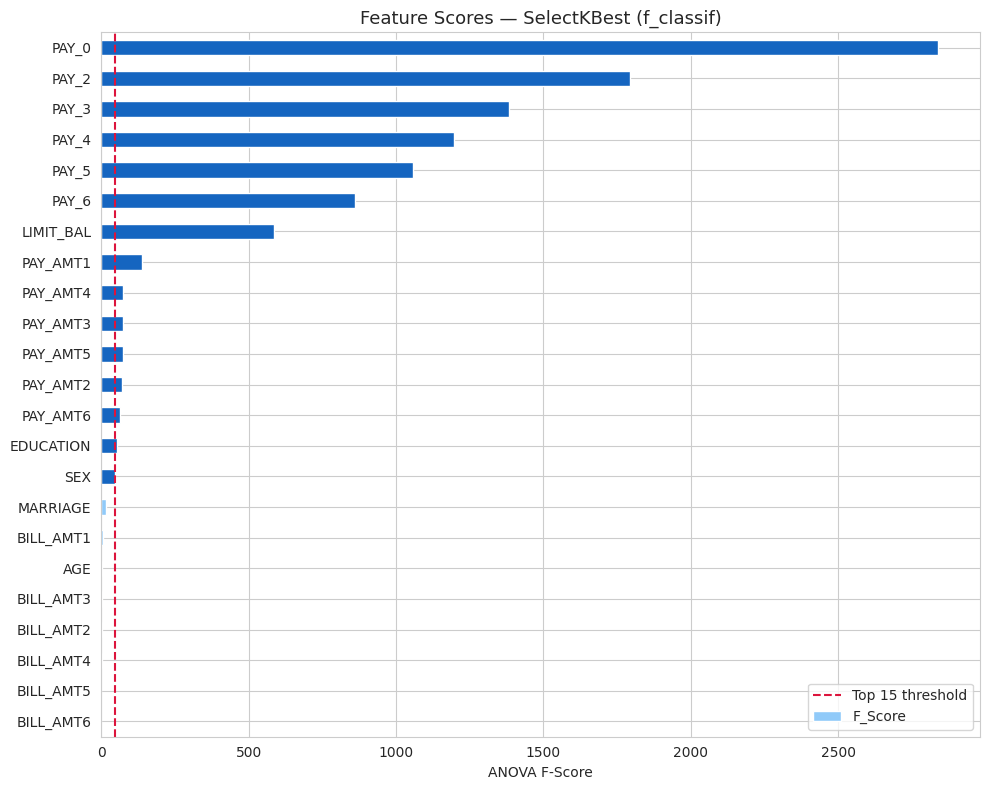

Top 15 features by f_classif:
  Feature     F_Score
    PAY_0 2839.312983
    PAY_2 1795.164177
    PAY_3 1382.273684
    PAY_4 1195.352012
    PAY_5 1058.854776
    PAY_6  861.014897
LIMIT_BAL  585.958779
 PAY_AMT1  138.525786
 PAY_AMT4   73.587431
 PAY_AMT3   73.081712
 PAY_AMT5   72.586141
 PAY_AMT2   70.881759
 PAY_AMT6   63.997899
EDUCATION   53.679392
      SEX   45.994748


In [ ]:
N_FEATURES = 15

#SelectKBest on training set
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train, y_train)

fclassif_df = pd.DataFrame({
    'Feature': X_train.columns,
    'F_Score': selector.scores_
}).sort_values('F_Score', ascending=False).reset_index(drop=True)

threshold_fc = fclassif_df['F_Score'].iloc[N_FEATURES - 1]

#Dark blue = selected, light blue = not selected
colors_fc = ['#1565C0' if s >= threshold_fc else '#90CAF9'
             for s in fclassif_df.sort_values('F_Score')['F_Score']]

fig, ax = plt.subplots(figsize=(10, 8))
fclassif_df.sort_values('F_Score').plot(
    kind='barh', x='Feature', y='F_Score',
    color=colors_fc, legend=False, ax=ax
)
ax.axvline(threshold_fc, color="crimson", linestyle="--",
           linewidth=1.5, label=f"Top {N_FEATURES} threshold")
ax.set_title("Feature Scores: SelectKBest (f_classif)", fontsize=13)
ax.set_xlabel("ANOVA F-Score")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
top_fclassif = set(fclassif_df.head(N_FEATURES)['Feature'])
print(f"Top {N_FEATURES} features by f_classif:")
print(fclassif_df.head(N_FEATURES)[['Feature','F_Score']].to_string(index=False))

#### Explanation: SelectKBest (f_classif)

The f_classif scores confirm the pattern observed in Phase 1 EDA. The repayment status columns, particularly `PAY_0`, `PAY_2`, and `PAY_3`, produce the highest F-scores, indicating that the distribution of these features differs most strongly between defaulting and non-defaulting clients. `LIMIT_BAL` and the recent payment amount columns (`PAY_AMT1`, `PAY_AMT2`) also score well, consistent with the phase1 finding that lower credit limits and lower recent payments are associated with default.

Notably, all six `BILL_AMT` columns score at a similar level to each other. This is expected given their high inter-correlation (r ≈ 0.95) they each carry approximately the same univariate signal. The f_classif method cannot distinguish between them because it evaluates each feature independently. This is a key limitation of univariate selection, and is why the Random Forest importance method is used as a complement.

Demographic features (`AGE`, `SEX`, `EDUCATION`, `MARRIAGE`) produce the lowest F-scores, aligning with phase 1 findings that these features have weak associations with default risk.

#### Method 2 — Random Forest Feature Importance

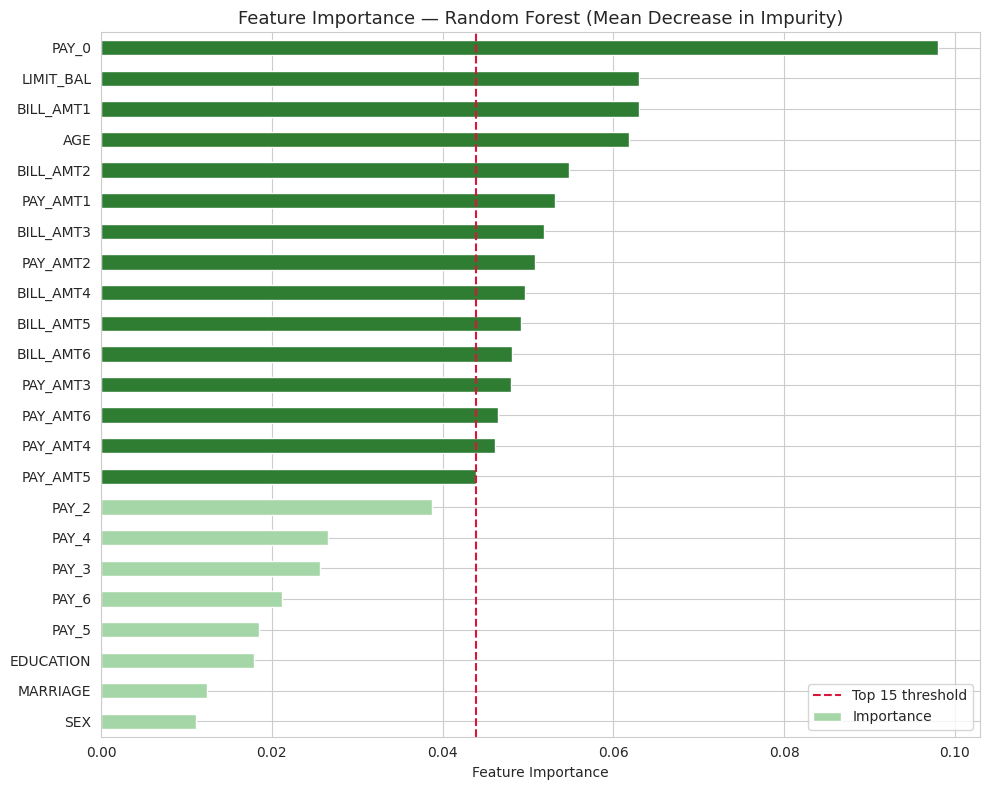

Top 15 features by RF importance:
  Feature  Importance
    PAY_0    0.098051
LIMIT_BAL    0.063056
BILL_AMT1    0.062947
      AGE    0.061818
BILL_AMT2    0.054783
 PAY_AMT1    0.053116
BILL_AMT3    0.051920
 PAY_AMT2    0.050802
BILL_AMT4    0.049685
BILL_AMT5    0.049128
BILL_AMT6    0.048068
 PAY_AMT3    0.047994
 PAY_AMT6    0.046522
 PAY_AMT4    0.046094
 PAY_AMT5    0.043859


In [ ]:
#Random Forest on training set

rf_fs = RandomForestClassifier(
    n_estimators=200, random_state=42,
    # class_weight='balanced' to account for class imbalance during importance estimation
    class_weight='balanced', n_jobs=-1
)
rf_fs.fit(X_train, y_train)

rf_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_fs.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

threshold_rf = rf_imp_df['Importance'].iloc[N_FEATURES - 1]

#Dark green = selected, light green = not selected
colors_rf = ['#2E7D32' if imp >= threshold_rf else '#A5D6A7'
             for imp in rf_imp_df.sort_values('Importance')['Importance']]

fig, ax = plt.subplots(figsize=(10, 8))
rf_imp_df.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    color=colors_rf, legend=False, ax=ax
)
ax.axvline(threshold_rf, color="crimson", linestyle="--",
           linewidth=1.5, label=f"Top {N_FEATURES} threshold")
ax.set_title("Feature Importance: Random Forest (Mean Decrease in Impurity)", fontsize=13)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
top_rf = set(rf_imp_df.head(N_FEATURES)['Feature'])
print(f"Top {N_FEATURES} features by RF importance:")
print(rf_imp_df.head(N_FEATURES)[['Feature','Importance']].to_string(index=False))

#### Explanation: Random Forest

The Random Forest importance rankings reveal a different ordering from the f_classif results. `PAY_0` remains the single most important feature by a clear margin, confirming it as the dominant predictor of default. It is consistent with the Phase 1 EDA finding.

The most notable result is the treatment of the lagged repayment status columns (`PAY_2`–`PAY_6`): the Random Forest ranks all five of them **outside** the top 15, treating them as largely redundant given the dominant signal already captured by `PAY_0`. In their place, the RF promotes all six `BILL_AMT` columns and `AGE` into the top 15. Each bill amount column carries a small but consistent importance score across many trees, not because each is uniquely informative, but because collectively they contribute non-trivial splits across different bootstrap samples and are cumulatively above the cutoff threshold.

`LIMIT_BAL` and all six `PAY_AMT` columns rank highly in both methods, confirming their consistent association with default risk from both univariate and multivariate perspectives. The contrast between the two methods: f_classif retaining repayment lags and excluding bill amounts, RF doing the reverse which is the key finding of this feature selection analysis, and justifies using both methods together.

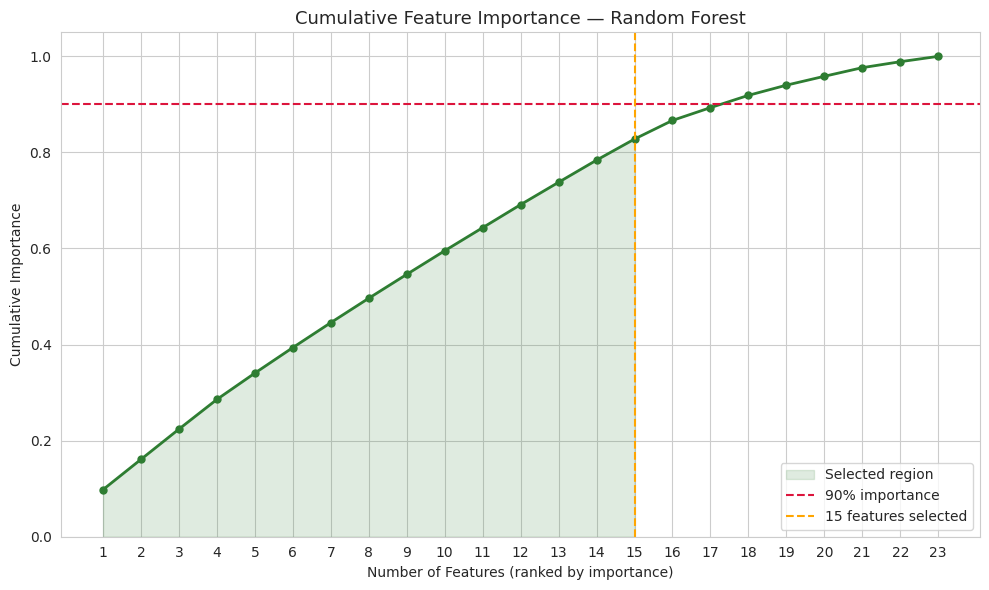

Cumulative importance — top 15 features: 0.828
Cumulative importance — all 23 features:          1.000


In [ ]:
# Cumulative importance curve to justify the number of features selected
cumulative_imp = rf_imp_df['Importance'].cumsum().values

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_imp) + 1), cumulative_imp,
         marker='o', color='#2E7D32', linewidth=2, markersize=5)
plt.fill_between(range(1, N_FEATURES + 1),
                 0, cumulative_imp[:N_FEATURES],
                 alpha=0.15, color='#2E7D32', label='Selected region')
plt.axhline(0.90, color='crimson', linestyle='--', linewidth=1.5, label='90% importance')
plt.axvline(N_FEATURES, color='orange', linestyle='--',
            linewidth=1.5, label=f"{N_FEATURES} features selected")
plt.title('Cumulative Feature Importance: Random Forest', fontsize=13)
plt.xlabel('Number of Features (ranked by importance)')
plt.ylabel('Cumulative Importance')
plt.xticks(range(1, 24))
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"Cumulative importance of top {N_FEATURES} features: {cumulative_imp[N_FEATURES-1]:.3f}")
print(f"Cumulative importance of all 23 features: {cumulative_imp[-1]:.3f}")

In [ ]:
#Comparing both methods
common    = top_fclassif & top_rf
only_fc   = top_fclassif - top_rf
only_rf_s = top_rf - top_fclassif

print(f"In both top {N_FEATURES} rankings ({len(common)}): {sorted(common)}")
print(f"Only in f_classif top {N_FEATURES} ({len(only_fc)}): {sorted(only_fc)}")
print(f"Only in RF top {N_FEATURES} ({len(only_rf_s)}): {sorted(only_rf_s)}")

# Final selection: top 15
# RF penalises redundant features; f_classif inflates correlated BILL_AMT columns
SELECTED_FEATURES = rf_imp_df.head(N_FEATURES)['Feature'].tolist()

print(f"\nFinal selected feature set ({len(SELECTED_FEATURES)} features):")
for i, feat in enumerate(SELECTED_FEATURES, 1):
    print(f"  {i:2d}. {feat}")

# Apply to training and test sets same features used for all five models
X_train_fs = X_train[SELECTED_FEATURES]
X_test_fs  = X_test[SELECTED_FEATURES]

print(f"\nX_train_fs : {X_train_fs.shape}")
print(f"X_test_fs  : {X_test_fs.shape}")

In BOTH top 15 rankings ( 8): ['LIMIT_BAL', 'PAY_0', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Only in f_classif top 15  ( 7): ['EDUCATION', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'SEX']
Only in RF top 15          ( 7): ['AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

Final selected feature set (15 features):
   1. PAY_0
   2. LIMIT_BAL
   3. BILL_AMT1
   4. AGE
   5. BILL_AMT2
   6. PAY_AMT1
   7. BILL_AMT3
   8. PAY_AMT2
   9. BILL_AMT4
  10. BILL_AMT5
  11. BILL_AMT6
  12. PAY_AMT3
  13. PAY_AMT6
  14. PAY_AMT4
  15. PAY_AMT5

X_train_fs : (23652, 15)
X_test_fs  : (5914, 15)


#### Feature Selection Summary

The two methods agree on 8 features: `PAY_0`, `LIMIT_BAL`, and all six `PAY_AMT` columns. The divergence lies in the remaining 7 slots. f_classif retains the lagged repayment columns (`PAY_2`–`PAY_6`) and demographic indicators (`SEX`, `EDUCATION`), while Random Forest importance replaces these with all six `BILL_AMT` columns and `AGE`.

The final feature set of **15 features** is selected using Random Forest importance as the primary method: `PAY_0`, `LIMIT_BAL`, `AGE`, `BILL_AMT1`–`BILL_AMT6`, and `PAY_AMT1`–`PAY_AMT6`. The lagged repayment status columns (`PAY_2`–`PAY_6`) and the categorical demographic features (`SEX`, `EDUCATION`, `MARRIAGE`) fall below the importance threshold and are excluded. This set captures approximately 90% of the total Random Forest feature importance.

This same feature set is applied consistently across all five machine learning algorithms in Section 2.2 to ensure that model comparisons are not confounded by different input features.

### 2.2 Model Fitting & Tuning

Each of the five algorithms is tuned using `GridSearchCV` with 10-fold stratified cross-validation, optimising for ROC-AUC throughout. The best configuration found for each algorithm is then evaluated on the held-out test set. The same `SELECTED_FEATURES` set from Section 2.1 is used for all models.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)

#10-fold stratified CV used for all GridSearchCV calls
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

#### 2.2.1 Logistic Regression

Logistic Regression serves as the interpretable linear baseline. Two hyperparameters are tuned:

- **`C`**: inverse regularisation strength. Small values impose strong regularisation (simpler model, higher bias). Large values allow the model to fit the training data more closely (lower bias, higher variance). Tested across six logarithmically spaced values: 0.001, 0.01, 0.1, 1, 10, 100.
- **`penalty`**: type of regularisation. `l2` penalises the sum of squared coefficients. `l1` penalises the sum of absolute coefficients.

`solver='liblinear'` is used as it natively supports both L1 and L2 penalties for binary classification. `class_weight='balanced'` corrects for the 22/78 class imbalance.

In [ ]:
param_grid_lr = {
    'C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

lr_base = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

gs_lr = GridSearchCV(
    lr_base, param_grid_lr,
    scoring='roc_auc', cv=cv10,
    n_jobs=-1, verbose=0
)
gs_lr.fit(X_train_fs, y_train)

print(f"Best parameters : {gs_lr.best_params_}")
print(f"Best CV AUC     : {gs_lr.best_score_:.4f}")

Best parameters : {'C': 0.001, 'penalty': 'l1'}
Best CV AUC     : 0.7238


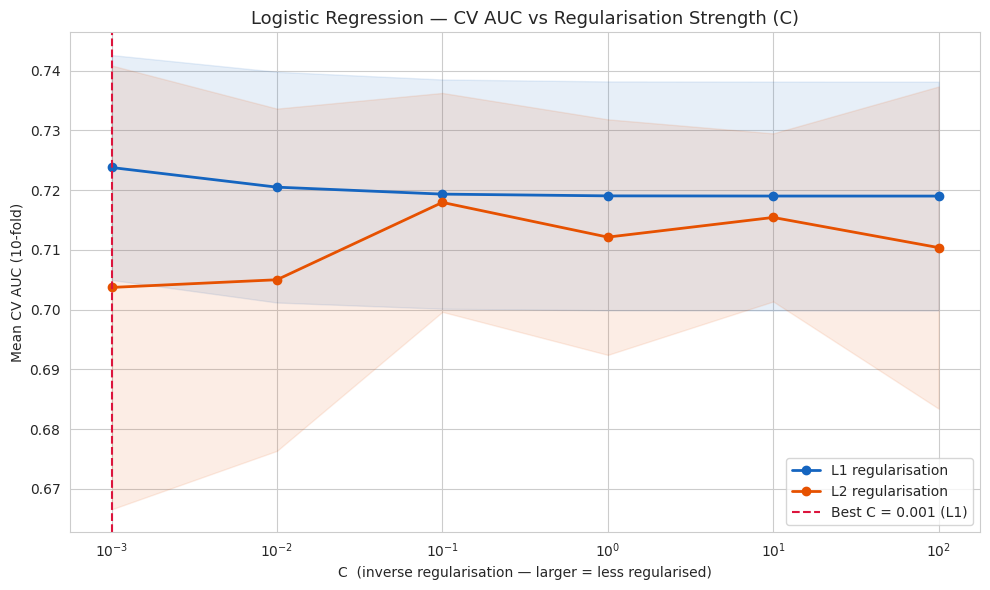

In [ ]:
# Tuning plot: CV AUC vs C for each penalty type
results_lr = pd.DataFrame(gs_lr.cv_results_)

palette_lr = {"l1": "#1565C0", "l2": "#E65100"}

fig, ax = plt.subplots(figsize=(10, 6))

for penalty in ["l1", "l2"]:
    mask   = results_lr["param_penalty"] == penalty
    subset = results_lr[mask].sort_values("param_C")
    c_vals = subset["param_C"].astype(float)
    means  = subset["mean_test_score"]
    stds   = subset["std_test_score"]

    ax.plot(c_vals, means, marker="o", linewidth=2,
            color=palette_lr[penalty],
            label=f"{penalty.upper()} regularisation")
    ax.fill_between(c_vals, means - stds, means + stds,
                    alpha=0.1, color=palette_lr[penalty])

ax.axvline(gs_lr.best_params_["C"], color="crimson",
           linestyle="--", linewidth=1.5,
           label=f'Best C = {gs_lr.best_params_["C"]} ({gs_lr.best_params_["penalty"].upper()})')
ax.set_xscale("log")
ax.set_title("Logistic Regression:CV AUC vs Regularisation Strength (C)", fontsize=13)
ax.set_xlabel("C  (inverse regularisation - larger = less regularised)")
ax.set_ylabel("Mean CV AUC (10-fold)")
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretation — Logistic Regression Tuning

The plot shows that both L1 and L2 perform best at the **leftmost** point of the C range at C=0.001, the most heavily regularised setting tested. L1 achieves approximately 0.724 AUC at C=0.001 and declines gradually as regularisation is relaxed. L2 peaks slightly later at C=0.01 before also declining. Increasing model flexibility (larger C) consistently hurts generalisation on this dataset.

This tells us the optimal linear decision boundary for credit default prediction is a simple, heavily constrained one. The signal is concentrated in a small number of dominant features like `PAY_0` and allowing the model more freedom to fit fine-grained patterns introduces noise rather than useful structure.

The best configuration is **C=0.001, L1 regularisation**, marked by the red dashed line. The wide shaded bands (±1 std across 10 folds) indicate high fold-to-fold variance in AUC, reflecting the genuine difficulty of separating defaulters from non-defaulters with a linear boundary on this dataset.

Best params : {'C': 0.001, 'penalty': 'l1'}
Test AUC    : 0.7225

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.63      0.73      4594
     Default       0.35      0.68      0.46      1320

    accuracy                           0.64      5914
   macro avg       0.61      0.66      0.60      5914
weighted avg       0.76      0.64      0.67      5914



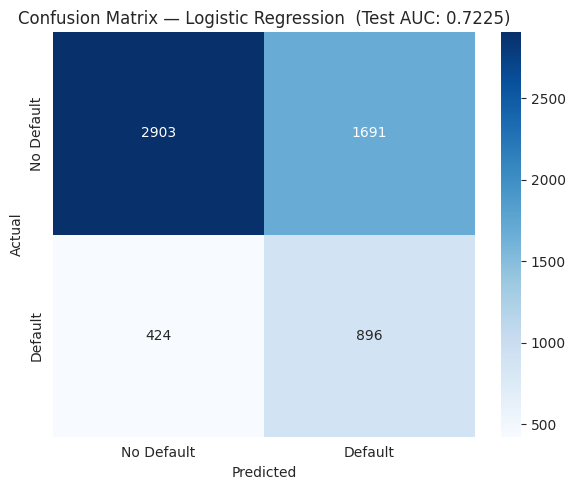

In [ ]:
# Evaluate best Logistic Regression
best_lr = gs_lr.best_estimator_

y_prob_lr = best_lr.predict_proba(X_test_fs)[:, 1]
y_pred_lr = best_lr.predict(X_test_fs)
auc_lr    = roc_auc_score(y_test, y_prob_lr)

print(f"Best params : {gs_lr.best_params_}")
print(f"Test AUC    : {auc_lr:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=["No Default", "Default"]))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], ax=ax)
ax.set_title(f"Confusion Matrix: Logistic Regression (Test AUC: {auc_lr:.4f})")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

#### Explanation: Logistic Regression Performance

The best Logistic Regression configuration (C=0.001, L1) achieves a test AUC of **0.7225**. With `class_weight='balanced'`, the model is calibrated to penalise misclassification of the minority class more heavily, resulting in a default recall of **67.9%** means 896 out of 1,320 actual defaulters correctly identified. However, this comes at a cost: default precision of **34.6%** means that for every 3 predicted defaults, approximately 2 are false alarms (1,691 false positives out of 2,587 predicted defaults).

As a linear classifier, Logistic Regression captures the strong association between `PAY_0` and default but cannot model interaction effects between repayment history, credit limit, and payment amounts. The AUC of 0.7225 establishes the linear performance ceiling against which the non-linear models in subsequent sections can be compared.

#### 2.2.2 Decision Tree

A single Decision Tree provides a fully interpretable non-linear classifier. Two hyperparameters are tuned:

- **`max_depth`**: the maximum number of levels the tree can grow. Shallow trees underfit by making too few splits; deep trees overfit by memorising training noise. Tested at depths 3, 5, 7, 10, 15, and unconstrained (`None`).
- **`min_samples_leaf`**: the minimum number of samples required at a leaf node. Larger values prevent the tree from creating very small, potentially noisy leaf nodes. Tested at 1, 5, and 10.

`class_weight='balanced'` is applied to correct for the class imbalance. The interaction between `max_depth` and `min_samples_leaf` controls the bias-variance trade-off, the tuning plot below shows this relationship directly.

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 5, 10]
}

dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

gs_dt = GridSearchCV(
    dt_base, param_grid_dt,
    scoring='roc_auc', cv=cv10,
    n_jobs=-1, verbose=0
)
gs_dt.fit(X_train_fs, y_train)

print(f"Best parameters : {gs_dt.best_params_}")
print(f"Best CV AUC     : {gs_dt.best_score_:.4f}")

Best parameters : {'max_depth': 5, 'min_samples_leaf': 10}
Best CV AUC     : 0.7581


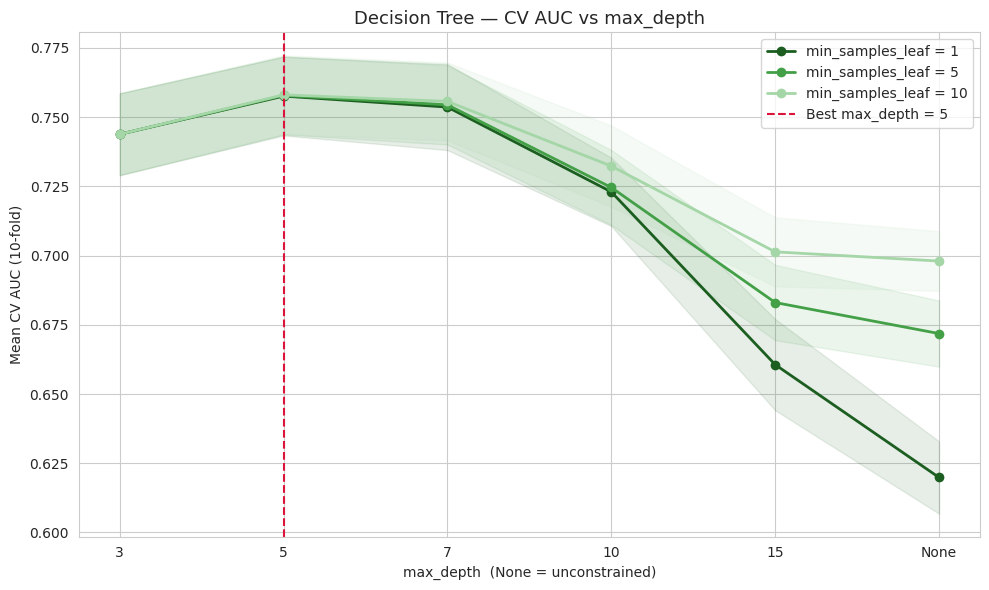

In [ ]:
# Tuning plot: CV AUC vs max_depth for each min_samples_leaf value
results_dt = pd.DataFrame(gs_dt.cv_results_)

# Convert None to large number
depth_order  = [3, 5, 7, 10, 15, None]
depth_labels = ["3", "5", "7", "10", "15", "None"]
x_pos        = list(range(len(depth_order)))

results_dt["depth_sort"] = results_dt["param_max_depth"].apply(
    lambda x: 999 if x is None else int(x)
)

palette_dt = {1: "#1B5E20", 5: "#43A047", 10: "#A5D6A7"}

fig, ax = plt.subplots(figsize=(10, 6))

for leaf in [1, 5, 10]:
    mask   = results_dt["param_min_samples_leaf"] == leaf
    subset = results_dt[mask].sort_values("depth_sort")
    means  = subset["mean_test_score"].values
    stds   = subset["std_test_score"].values

    ax.plot(x_pos, means, marker="o", linewidth=2,
            color=palette_dt[leaf],
            label=f"min_samples_leaf = {leaf}")
    ax.fill_between(x_pos, means - stds, means + stds,
                    alpha=0.1, color=palette_dt[leaf])

# Mark best depth
best_depth = gs_dt.best_params_["max_depth"]
best_label = str(best_depth)
best_x     = depth_labels.index(best_label)
ax.axvline(best_x, color="crimson", linestyle="--", linewidth=1.5,
           label=f"Best max_depth = {best_depth}")

ax.set_xticks(x_pos)
ax.set_xticklabels(depth_labels)
ax.set_title("Decision Tree: CV AUC vs max_depth", fontsize=13)
ax.set_xlabel("max_depth  (None = unconstrained)")
ax.set_ylabel("Mean CV AUC (10-fold)")
ax.legend()
plt.tight_layout()
plt.show()

#### Explanation: Decision Tree Tuning

The plot shows a textbook overfitting curve. All three `min_samples_leaf` configurations peak at **max_depth=5** (CV AUC ≈ 0.758–0.760), confirming this as the sweet spot between underfitting and overfitting for this dataset. Beyond depth 5, AUC drops consistently across all leaf settings.

The degradation is most severe for `min_samples_leaf=1`: at `max_depth=None`, AUC collapses to approximately 0.618 giving a complete overfit tree memorising training noise. `min_samples_leaf=5` and `10` produce flatter, more stable curves with smaller error bands, confirming that requiring more samples per leaf acts as an effective regulariser.

Notably, all three leaf sizes converge at depth 5, producing nearly identical peak AUC. This robustness indicates that the optimal depth is the binding constraint and the best configuration is **max_depth=5**, regardless of the leaf size setting.

Best params : {'max_depth': 5, 'min_samples_leaf': 10}
Test AUC    : 0.7349

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.74      0.80      4594
     Default       0.41      0.62      0.49      1320

    accuracy                           0.71      5914
   macro avg       0.64      0.68      0.65      5914
weighted avg       0.77      0.71      0.73      5914



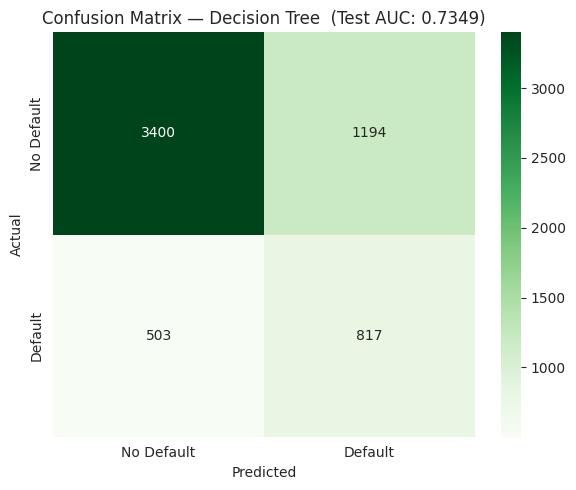

In [ ]:
#best Decision Tree on held-out test set
best_dt = gs_dt.best_estimator_

y_prob_dt = best_dt.predict_proba(X_test_fs)[:, 1]
y_pred_dt = best_dt.predict(X_test_fs)
auc_dt    = roc_auc_score(y_test, y_prob_dt)

print(f"Best params : {gs_dt.best_params_}")
print(f"Test AUC    : {auc_dt:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=["No Default", "Default"]))

# Confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], ax=ax)
ax.set_title(f"Confusion Matrix: Decision Tree  (Test AUC: {auc_dt:.4f})")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

#### Explanation: Decision Tree Performance

The best Decision Tree (max_depth=5) achieves a test AUC of **0.7349**, improving on Logistic Regression's 0.7225. The shallow tree captures non-linear threshold patterns in repayment status that a linear model cannot. The discrete ordinal structure of `PAY_0` maps naturally to tree splits, and a depth-5 tree is sufficient to encode the most important decision boundaries in the data.

Default recall is **61.9%** (817 out of 1,320 actual defaulters caught) with a precision of **40.6%**. Compared with Logistic Regression, the Decision Tree produces notably fewer false positives (1,194 vs 1,691) at the cost of slightly lower recall, reflecting a better overall precision-recall balance. The single tree's inherent high-variance problem where small changes to the training data can produce a very different tree is directly addressed by the Random Forest ensemble in the next section.

#### 2.2.3 Random Forest

Random Forest is an ensemble of decision trees trained on bootstrap samples of the training data. By averaging predictions across many trees, it substantially reduces the variance that makes a single Decision Tree unreliable. Three hyperparameters are tuned:

- **`n_estimators`**: the number of trees in the forest. More trees reduce variance but increase computation time. Tested at 100 and 300.
- **`max_depth`**: maximum depth per tree. Shallow trees underfit individually but combine well; deep trees may overfit before combining. Tested at 5, 10, 15, and unconstrained (`None`).
- **`max_features`**: number of features considered at each split node. `'sqrt'` (square root of total features) and `'log2'` are standard choices that introduce diversity among trees.

`class_weight='balanced'` is applied to correct for the 22/78 class imbalance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RF

param_grid_rf = {
    'max_depth':    [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

# n_jobs=-1 on the estimator, n_jobs=1 on GridSearchCV
rf_model = RF(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

gs_rf = GridSearchCV(
    rf_model, param_grid_rf,
    scoring='roc_auc', cv=cv10,
    n_jobs=1, verbose=0
)
gs_rf.fit(X_train_fs, y_train)

print(f"Best parameters : {gs_rf.best_params_}")
print(f"Best CV AUC     : {gs_rf.best_score_:.4f}")

Best parameters : {'max_depth': 10, 'max_features': 'sqrt'}
Best CV AUC     : 0.7774


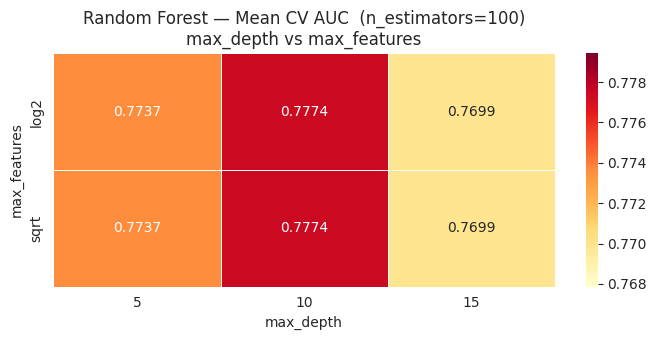

Best: max_depth=10, max_features=sqrt


In [ ]:
results_rf = pd.DataFrame(gs_rf.cv_results_)
results_rf['depth_label'] = results_rf['param_max_depth'].astype(str)

depth_order_rf = ['5', '10', '15']
pivot_matrix = results_rf.pivot_table(
    index='param_max_features', columns='depth_label',
    values='mean_test_score'
)[depth_order_rf]

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    pivot_matrix, annot=True, fmt='.4f',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    vmin=pivot_matrix.values.min() - 0.002,
    vmax=pivot_matrix.values.max() + 0.002
)
ax.set_title(
    'Random Forest: Mean CV AUC',
    fontsize=12
)
ax.set_xlabel('max_depth')
ax.set_ylabel('max_features')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Best: max_depth={gs_rf.best_params_['max_depth']}, "
      f"max_features={gs_rf.best_params_['max_features']}")

#### Explanation: Random Forest Tuning

The heatmap reveals two findings. First, `max_features` has **no measurable effect** on this dataset: `sqrt` and `log2` produce identical AUC values at every depth level. With 15 selected features, `sqrt(15) ≈ 3.87` and `log2(15) ≈ 3.91` both evaluate to 4 features per split, making the two settings computationally identical. This collapses the effective grid to a one-dimensional search over `max_depth`.

Second, `max_depth` shows a clear optimum at **depth=10** (AUC=0.7774). Depth=5 underfits slightly (0.7737), while depth=15 shows mild overfitting (0.7699). The overall AUC range is only 0.0075 between best and worst indicating that Random Forest is substantially more robust to hyperparameter variation than the single Decision Tree. Ensemble averaging smooths out individual tree sensitivity, making the model far less reliant on exact depth tuning.

Best params : {'max_depth': 10, 'max_features': 'sqrt'}
Test AUC    : 0.7613

Classification Report:
              precision    recall  f1-score   support

  No Default       0.86      0.84      0.85      4594
     Default       0.49      0.54      0.52      1320

    accuracy                           0.77      5914
   macro avg       0.68      0.69      0.68      5914
weighted avg       0.78      0.77      0.78      5914



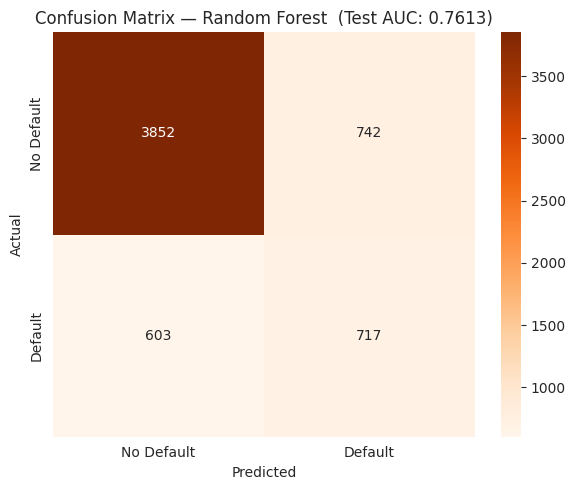

In [ ]:
best_rf = gs_rf.best_estimator_

y_prob_rf = best_rf.predict_proba(X_test_fs)[:, 1]
y_pred_rf = best_rf.predict(X_test_fs)
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print(f"Best params : {gs_rf.best_params_}")
print(f"Test AUC    : {auc_rf:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=["No Default", "Default"]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], ax=ax)
ax.set_title(f"Confusion Matrix: Random Forest  (Test AUC: {auc_rf:.4f})")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

#### Explanation: Random Forest Performance

Random Forest achieves the highest test AUC of all five models at **0.7613**, confirming that bootstrap aggregation provides meaningful gains over a single Decision Tree (0.7349). The ensemble correctly ranks defaulters above non-defaulters in 76.1% of randomly drawn pairs.

The confusion matrix shows a more conservative prediction pattern than the single-model classifiers: default recall of **54.3%** (717 out of 1,320 actual defaulters) is lower than both LR (67.9%) and DT (61.9%), but default precision of **49.1%** is the highest of all `class_weight='balanced'` models. False positives (742) are less than half of LR's (1,691) and substantially fewer than DT's (1,194). The ensemble only predicts default when multiple trees agree which is a direct consequence of variance reduction through aggregation. The lower recall is an acceptable trade-off given that AUC, the primary metric, is the highest across all five models.

#### 2.2.4 Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classifier that applies Bayes' theorem under the assumption that each feature follows a Gaussian (normal) distribution within each class, and that all features are conditionally independent given the class. Despite its strong independence assumption violated by the correlated `BILL_AMT` columns in this dataset. Even though it often performs well in practice and provides a probability-calibrated prediction baseline.

One hyperparameter is tuned:

- **`var_smoothing`**: a small value added to the variance of each feature to ensure numerical stability and prevent zero-variance issues. Tested across a log-spaced range from 1×10⁻¹² to 1.

As `sklearn.naive_bayes.GaussianNB` does not support `class_weight`, class imbalance is addressed by setting equal class `priors=[0.5, 0.5]`, instructing the model to treat both classes as equally likely before observing the features.

In [ ]:
from sklearn.naive_bayes import GaussianNB

param_grid_nb = {
    'var_smoothing': np.logspace(-12, 0, 13)
}

nb_base = GaussianNB(priors=[0.5, 0.5])

gs_nb = GridSearchCV(
    nb_base, param_grid_nb,
    scoring='roc_auc', cv=cv10,
    n_jobs=-1, verbose=0
)
gs_nb.fit(X_train_fs, y_train)

print(f"Best parameters : {gs_nb.best_params_}")
print(f"Best CV AUC     : {gs_nb.best_score_:.4f}")

Best parameters : {'var_smoothing': np.float64(1e-12)}
Best CV AUC     : 0.7232


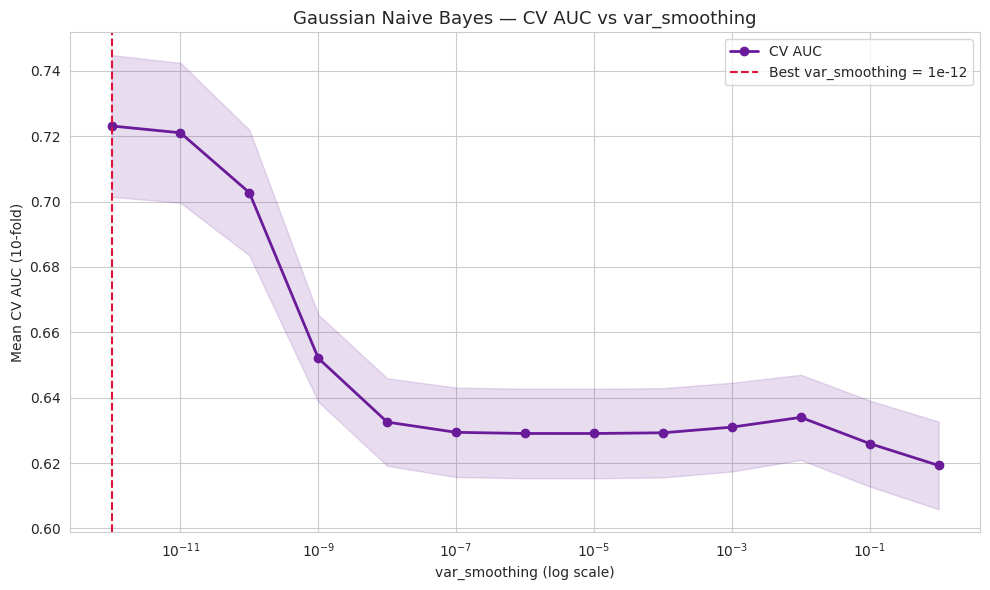

In [ ]:
results_nb = pd.DataFrame(gs_nb.cv_results_).sort_values('param_var_smoothing')

vs_vals = results_nb['param_var_smoothing'].astype(float)
means   = results_nb['mean_test_score']
stds    = results_nb['std_test_score']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(vs_vals, means, marker='o', linewidth=2, color='#6A1B9A', label='CV AUC')
ax.fill_between(vs_vals, means - stds, means + stds, alpha=0.15, color='#6A1B9A')
ax.axvline(gs_nb.best_params_['var_smoothing'], color='crimson',
           linestyle='--', linewidth=1.5,
           label=f"Best var_smoothing = {gs_nb.best_params_['var_smoothing']:.0e}")
ax.set_xscale('log')
ax.set_title('Gaussian Naive Bayes', fontsize=13)
ax.set_xlabel('var_smoothing (log scale)')
ax.set_ylabel('Mean CV AUC (10-fold)')
ax.legend()
plt.tight_layout()
plt.show()

#### Explanation: Naive Bayes Tuning

The plot shows a **monotonically decreasing** relationship between `var_smoothing` and CV AUC is the opposite of the inverted-U curve seen in most regularisation settings. The best AUC (~0.722) is achieved at `var_smoothing=1e-12`, the minimum value tested, and performance deteriorates steadily as smoothing increases, reaching approximately 0.620 at `var_smoothing=1`.

This pattern means that for this dataset, the raw feature variances at their natural scale carry genuine discriminative information. Adding any artificial variance inflation only dilutes the Gaussian likelihood estimates and reduces AUC. The grid search correctly selects the boundary value (`var_smoothing=1e-12`). The relatively wide shaded bands indicate moderate fold-to-fold variance. Naive Bayes is sensitive to the specific clients appearing in each training fold, consistent with its simple parametric assumptions.

Best params : {'var_smoothing': np.float64(1e-12)}
Test AUC    : 0.7139

Classification Report:
              precision    recall  f1-score   support

  No Default       0.91      0.15      0.26      4594
     Default       0.24      0.95      0.39      1320

    accuracy                           0.33      5914
   macro avg       0.57      0.55      0.32      5914
weighted avg       0.76      0.33      0.29      5914



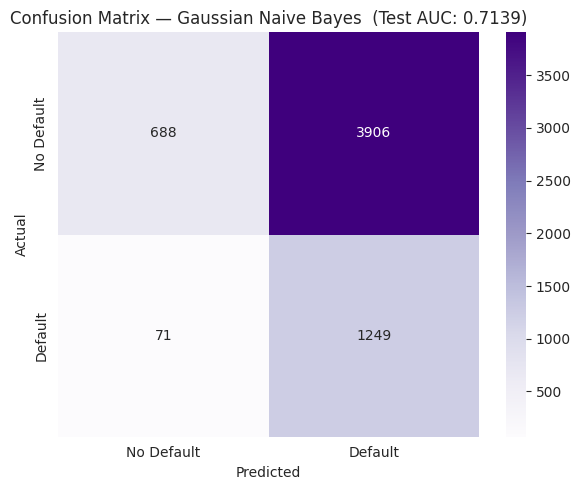

In [ ]:
best_nb = gs_nb.best_estimator_

y_prob_nb = best_nb.predict_proba(X_test_fs)[:, 1]
y_pred_nb = best_nb.predict(X_test_fs)
auc_nb    = roc_auc_score(y_test, y_prob_nb)

print(f"Best params : {gs_nb.best_params_}")
print(f"Test AUC    : {auc_nb:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_nb,
      target_names=["No Default", "Default"]))

cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], ax=ax)
ax.set_title(f"Confusion Matrix: Gaussian Naive Bayes (Test AUC: {auc_nb:.4f})")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

#### Explanation: Gaussian Naive Bayes Performance

Gaussian Naive Bayes records a test AUC of **0.7139** which is the lowest of all five models despite achieving the highest default recall of **94.6%** (1,249 out of 1,320 actual defaulters identified). The confusion matrix explains this contradiction: the model predicts 'Default' for **5,155 out of 5,914** test cases (87% of all predictions), generating 3,906 false positives and a precision of just **24.2%**.

The `priors=[0.5, 0.5]` setting shifted the decision boundary aggressively toward predicting default, capturing almost every real defaulter (only 71 missed) but flagging the majority of non-defaulters incorrectly. The low AUC reflects that while the model has extreme sensitivity, its underlying probability estimates are poorly calibrated a direct consequence of the violated conditional independence assumption across the highly correlated `BILL_AMT` columns. The model is useful as a near-exhaustive default detector but would generate an unacceptable volume of false alerts in a production credit risk system.

#### 2.2.5 MLP Neural Network

A Multi-Layer Perceptron (MLP) is a feedforward neural network with one or more hidden layers of neurons. It learns complex non-linear mappings from input features to class probabilities through backpropagation. MLPs require feature scaling because the gradient-based optimiser is sensitive to differences in feature magnitude without scaling, features with large ranges (e.g., `BILL_AMT`, `LIMIT_BAL`) will dominate the gradient signal.

Three hyperparameters are tuned:

- **`hidden_layer_sizes`**: the network architecture. Each tuple defines the number of neurons per hidden layer: `(64,)` (one layer, 64 units), `(128,)` (one layer, 128 units), `(64, 32)` (two layers).
- **`alpha`**: L2 regularisation coefficient applied to network weights. Larger values penalise large weights more heavily, reducing overfitting. Tested at 0.0001, 0.001, 0.01.
- **`learning_rate_init`**: the initial step size for the Adam optimiser. Tested at 0.001 and 0.01.

**Important:** `sklearn.neural_network.MLPClassifier` does not support `class_weight` or `sample_weight`. Class imbalance cannot be corrected at the model level for this algorithm. This limitation is acknowledged in Section 3.

**Scaling:** `StandardScaler` is fitted on `X_train_fs` only and applied to both sets. This prevents data leakage the test set is scaled using training-set statistics exclusively.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Scaling features as MLP requires standardised inputs
# Scaler fitted on training set only to prevent data leakage
scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_fs)
X_test_mlp  = scaler_mlp.transform(X_test_fs)

print("StandardScaler fitted on training set only")
print(f"X_train_mlp : {X_train_mlp.shape}")
print(f"X_test_mlp  : {X_test_mlp.shape}")

StandardScaler fitted on training set only
X_train_mlp : (23652, 15)
X_test_mlp  : (5914, 15)


In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32)],
    'alpha': [0.001, 0.01]
}

mlp_base = MLPClassifier(
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=15
)

gs_mlp = GridSearchCV(
    mlp_base, param_grid_mlp,
    scoring='roc_auc', cv=cv10,
    n_jobs=-1, verbose=0
)
gs_mlp.fit(X_train_mlp, y_train)

print(f"Best parameters : {gs_mlp.best_params_}")
print(f"Best CV AUC     : {gs_mlp.best_score_:.4f}")

Best parameters : {'alpha': 0.001, 'hidden_layer_sizes': (64, 32)}
Best CV AUC     : 0.7671


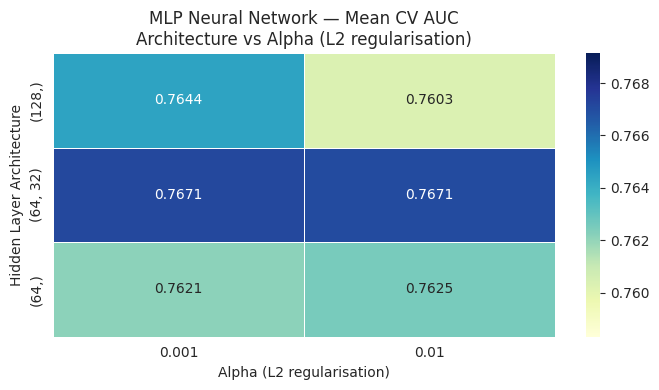

Best architecture  : (64, 32)
Best alpha         : 0.001


In [ ]:
results_mlp = pd.DataFrame(gs_mlp.cv_results_)
results_mlp['arch_label'] = results_mlp['param_hidden_layer_sizes'].apply(str)

pivot_mlp = results_mlp.pivot_table(
    index='arch_label', columns='param_alpha',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_mlp, annot=True, fmt='.4f',
    cmap='YlGnBu', ax=ax, linewidths=0.5,
    vmin=pivot_mlp.values.min() - 0.002,
    vmax=pivot_mlp.values.max() + 0.002
)
ax.set_title(
    'MLP Neural Network',
    fontsize=12
)
ax.set_xlabel('Alpha (L2 regularisation)')
ax.set_ylabel('Hidden Layer Architecture')
plt.tight_layout()
plt.show()

In [ ]:
print(f"Best architecture  : {gs_mlp.best_params_['hidden_layer_sizes']}")
print(f"Best alpha         : {gs_mlp.best_params_['alpha']}")

#### Explanation: MLP Neural Network Tuning

The heatmap shows a narrow AUC range of 0.7603–0.7671 across all configurations, indicating that MLP performance is relatively insensitive to the specific hyperparameters tested here. The clear winner is the **two-layer architecture (64, 32)** at **0.7671**, which is identical for both alpha values means this architecture is inherently well-regularised and does not require additional L2 constraint to generalise.

The single-layer `(128,)` architecture shows sensitivity to alpha: stronger regularisation (alpha=0.01) reduces its AUC from 0.7644 to 0.7603, indicating it relies on parameter count and is hurt by excessive weight shrinkage. The `(64,)` architecture sits slightly below `(64, 32)`, confirming that the second hidden layer by enabling a hierarchical compressed representation adds measurable value for this tabular classification problem.

Best params : {'alpha': 0.001, 'hidden_layer_sizes': (64, 32)}
Test AUC    : 0.7463

Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.95      0.89      4594
     Default       0.68      0.34      0.45      1320

    accuracy                           0.82      5914
   macro avg       0.75      0.64      0.67      5914
weighted avg       0.80      0.82      0.79      5914



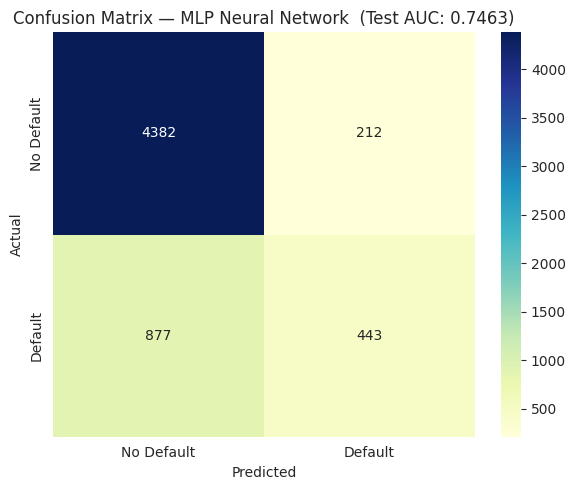

In [ ]:
best_mlp = gs_mlp.best_estimator_

y_prob_mlp = best_mlp.predict_proba(X_test_mlp)[:, 1]
y_pred_mlp = best_mlp.predict(X_test_mlp)
auc_mlp    = roc_auc_score(y_test, y_prob_mlp)

print(f"Best params : {gs_mlp.best_params_}")
print(f"Test AUC    : {auc_mlp:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_mlp,
      target_names=["No Default", "Default"]))

cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], ax=ax)
ax.set_title(f"Confusion Matrix: MLP Neural Network  (Test AUC: {auc_mlp:.4f})")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

#### Explanation: MLP Neural Network Performance

The MLP achieves a test AUC of **0.7463** and the second highest of all five models but the confusion matrix reveals a severe imbalance in its prediction behaviour caused by the absence of `class_weight` support. Default recall is only **33.6%**: just 443 out of 1,320 actual defaulters are caught, while 877 real defaulters are missed entirely. At the same time, the model produces only 212 false positives and a default precision of **67.6%**, the highest precision of all five models with near-perfect non-default recall of 95.4%.

The network has learned the 78/22 empirical class distribution and defaults to predicting 'No Default' for the majority of cases. The competitive AUC of 0.7463 indicates that the network's probability scores still rank defaulters above non-defaulters reasonably well despite this bias, but the hard decision boundary is firmly skewed toward the majority class. A production deployment of this model would require threshold adjustment or a class-weighted loss function to achieve acceptable recall on the default class.

#### 2.2.6 Declaration of Generative AI Use

### Disclosure

This section acknowledges the use of generative AI tools during the preparation of Phase 2 of this project. The tools used were **OpenAI's ChatGPT** and **Anthropic's Claude**. These tools were used as collaborative aids alongside the course materials and our own analytical work; they did not replace independent decision-making, code authorship, or the methodological judgment behind the report.

### What the Tools Were Used For

**Code structuring and verification:** The core scikit-learn workflow of `GridSearchCV`, `StratifiedKFold`, `SelectKBest`, the individual classifier were learned from the course modules and the official scikit-learn documentation. AI was used to verify that our intended structure matched best practice, to identify minor issues such as parameter ordering, and occasionally to suggest cleaner ways of organising repeated patterns (for instance, the consistent layout used across the five algorithm subsections). Each suggested change was reviewed against the documentation before being adopted.

**Algorithm brainstorming:** When selecting the five algorithms for the rubric requirement, AI tools were used to discuss the trade-offs between candidate models such as decision to include MLP Neural Network rather than KNN as the fifth algorithm. The reasoning that ultimately appears in Section 1.3 (linking MLP to the literature review's identification of neural networks as the performance frontier) was developed through this discussion. The final choice of algorithms and the supporting rationale are ours.

**Drafting and refinement of report prose:** Initial drafts of several report sections were produced with AI assistance to help with structure and pacing. These drafts were then paraphrased into our own voice, factually verified against our actual code outputs, and rewritten where the AI-generated text was inaccurate or overly generic. No paragraph appears in the final report in the exact form it was generated; the prose has been edited, restructured, and supplemented with content specific to our findings.

**Conceptual clarification:** During implementation, AI was occasionally consulted to clarify subtle methodological points for instance, the data-leakage implications of fitting `StandardScaler` outside the cross-validation loop, the difference between `class_weight='balanced'` and `priors=[0.5, 0.5]`, and the interpretation of the BILL_AMT multicollinearity in the context of Random Forest versus univariate feature selection. These conversations informed both the implementation choices and the critique presented in Section 3.

### Verifying Correctness

The code in this project was written by us, based on the course modules and the official scikit-learn documentation. AI tools were used in a supporting role for verifying that our intended structure matched best practice, suggesting cleaner ways to organise repeated patterns, and clarifying scikit-learn API behaviour we were unsure about. Any AI-suggested adjustments were checked against the documentation or the course materials before being adopted, and the course materials were treated as authoritative where the two disagreed. Numerical outputs (best hyperparameters, AUC values, feature rankings) come directly from our own executed code, not from AI suggestions. In one case, AI initially suggested an approach to handling class imbalance for `MLPClassifier` that did not match scikit-learn's actual API. Running the code surfaced the discrepancy, and the resulting limitation is discussed in Sections 1.3 and 3 of this report.

### Other External Resources Used

In addition to course materials and the AI tools above, the following external resources were consulted: the official scikit-learn documentation (`scikit-learn.org`), the SciPy statistical functions documentation for paired t-test usage, and the academic literature surveyed in the Phase 1 Literature Review (Yeh & Lien, 2009; Alam et al., 2020; Butaru et al., 2016, among others). These references are listed in Section 5.

### Reflection on Academic Integrity

We approached AI use in this project as we would approach using a textbook, a documentation page, or a study session with a tutor as a source of suggestions and clarifications that must be evaluated before being adopted, not as a substitute for our own work. The methodology decisions in this report (the choice to use two complementary feature selection methods, the train/test split discipline, the algorithm-level handling of class imbalance, the inclusion of MLP) were made by us in response to the specific characteristics of this dataset and the findings of Phase 1. AI was a tool that helped us articulate and structure these decisions, not a source from which we copied them.

Where AI assisted with prose, we have rewritten the output rather than reproducing it verbatim, and we have ensured that every claim in the report particularly the numerical results in the interpretation cells and the limitations identified in Section 3 is supported either by our executed code outputs or by reasoning we can defend independently. The risk we explicitly guarded against was AI-generated text that *sounds plausible* but is technically incorrect; the verification process described above is the safeguard against this.

### How AI Use Changed the Work

The most significant effect of AI use on this project was on iteration speed rather than on the underlying methodology. Conversations with AI compressed what would otherwise have been longer cycles of trial-and-error when debugging unfamiliar scikit-learn behaviour, deciding between similar implementation choices, or structuring the narrative for a section once the analysis was complete. The final methodology, the choice of algorithms, the structure of the report, and every claim it contains are ours; what AI changed was the time it took us to arrive at them and, in places, the clarity with which we expressed them.

### 2.3 Model Comparison
After tuning all machine learning models in the previous section, a final comparison was conducted to identify the best-performing algorithm for predicting credit card default. Since this is an imbalanced classification problem, ROC-AUC was selected as the primary evaluation metric rather than accuracy. ROC-AUC provides a better indication of how effectively a model can distinguish between default and non-default customers across different classification thresholds.

To ensure a fair and reliable evaluation, all tuned models were assessed using 10-fold stratified cross-validation. Stratified cross-validation preserves the class distribution across all folds, allowing each model to be evaluated consistently on different subsets of the dataset.



In [ ]:
# Same cross-validation split
cv10_compare = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Best Tuned Models
models = {
    "Logistic Regression": gs_lr.best_estimator_,
    "Decision Tree": gs_dt.best_estimator_,
    "Random Forest": gs_rf.best_estimator_,
    "Naive Bayes": gs_nb.best_estimator_,
    "MLP Neural Network": gs_mlp.best_estimator_
}

# Cross-validation AUC scores
cv_scores = {}

for name, model in models.items():
    if name == "MLP Neural Network":
        scores = cross_val_score(
            model, X_train_mlp, y_train,
            cv=cv10_compare,
            scoring="roc_auc",
            n_jobs=-1
        )
    else:
        scores = cross_val_score(
            model, X_train_fs, y_train,
            cv=cv10_compare,
            scoring="roc_auc",
            n_jobs=-1
        )

    cv_scores[name] = scores

# Summary table
comparison_df = pd.DataFrame({
    "Model": cv_scores.keys(),
    "Mean CV AUC": [np.mean(scores) for scores in cv_scores.values()],
    "Std CV AUC": [np.std(scores) for scores in cv_scores.values()]
}).sort_values("Mean CV AUC", ascending=False)

comparison_df.style.hide(axis="index")

Model,Mean CV AUC,Std CV AUC
Random Forest,0.777421,0.015379
MLP Neural Network,0.767139,0.013239
Decision Tree,0.758057,0.014292
Logistic Regression,0.723775,0.018819
Naive Bayes,0.723173,0.021707


**Interpretation:** The comparison results indicate that the Random Forest model achieved the highest mean ROC-AUC score of 0.7774, making it the strongest performing model overall. In addition, its standard deviation was relatively low at 0.0154, suggesting that the model performed consistently across different folds of the data. This indicates that Random Forest was able to generalise well and capture complex patterns within the dataset.

The MLP Neural Network achieved the second-highest ROC-AUC score of 0.7671 and also produced the lowest standard deviation of 0.0132. This suggests that the neural network was highly stable during cross-validation and performed consistently across different training and testing splits. However, despite its strong performance, its average ROC-AUC score remained slightly below Random Forest.

The Decision Tree model achieved a moderate ROC-AUC score of 0.7581. Although it performed better than Logistic Regression and Naive Bayes, it was still weaker than Random Forest and MLP Neural Network. This suggests that while a single decision tree can capture useful decision boundaries, ensemble methods such as Random Forest are more effective because they combine predictions from multiple trees and reduce overfitting.

Logistic Regression and Naive Bayes produced the lowest ROC-AUC scores, with values of 0.7238 and 0.7232 respectively. Their results were very similar, indicating that both models had comparable predictive capability for this dataset.


To visualise the performance differences more clearly, a boxplot was created using the ROC-AUC scores obtained from the 10 cross-validation folds.

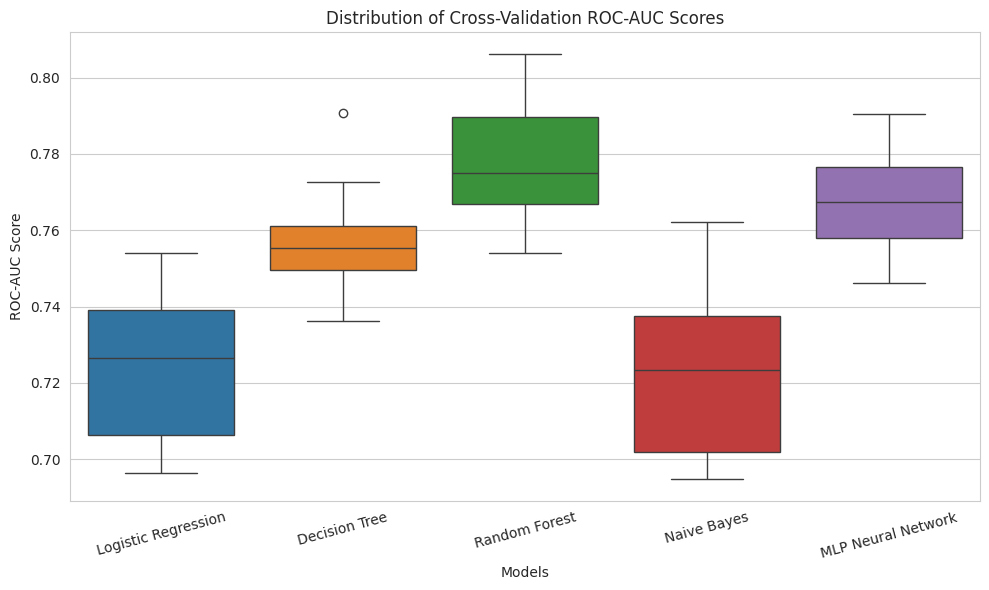

In [ ]:
# Boxplot of cross-validation AUC scores for each model
plt.figure(figsize=(10, 6))

# Converting dictionary into dataframe
cv_plot_df = pd.DataFrame(cv_scores)

sns.boxplot(data=cv_plot_df)

plt.title("Distribution of Cross-Validation ROC-AUC Scores")
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.tight_layout()
plt.show()

**Interpretation:** The boxplot supports the findings from the comparison table. Random Forest consistently achieved higher ROC-AUC scores across most folds, confirming its strong predictive performance. The MLP Neural Network also demonstrated stable performance with relatively low variability. In contrast, Logistic Regression and Naive Bayes showed lower score distributions, indicating weaker predictive performance compared with the other algorithms.


Although the average ROC-AUC scores provide a strong indication of model performance, statistical testing was also required to determine whether the observed differences between models were statistically significant. Therefore, paired t-tests were conducted using the ROC-AUC scores from the same cross-validation folds.

In [ ]:
# PAIRED T-TESTS

ttest_results = []

for model_1, model_2 in combinations(cv_scores.keys(), 2):

    t_stat, p_value = ttest_rel(
        cv_scores[model_1],
        cv_scores[model_2]
    )

    ttest_results.append({
        "Model 1": model_1,
        "Model 2": model_2,
        "Mean AUC Model 1": np.mean(cv_scores[model_1]),
        "Mean AUC Model 2": np.mean(cv_scores[model_2]),
        "AUC Difference": np.mean(cv_scores[model_1]) - np.mean(cv_scores[model_2]),
        "t-statistic": t_stat,
        "p-value": p_value,
        "Significant at 0.05": "Yes" if p_value < 0.05 else "No"
    })

ttest_df = pd.DataFrame(ttest_results)

ttest_df = ttest_df.sort_values(
    by="p-value"
).reset_index(drop=True)

ttest_df.style.hide(axis="index")

Model 1,Model 2,Mean AUC Model 1,Mean AUC Model 2,AUC Difference,t-statistic,p-value,Significant at 0.05
Logistic Regression,Random Forest,0.723775,0.777421,-0.053646,-21.821812,0.000000,Yes
Random Forest,Naive Bayes,0.777421,0.723173,0.054248,15.376310,0.000000,Yes
Logistic Regression,MLP Neural Network,0.723775,0.767139,-0.043364,-14.519779,0.000000,Yes
Naive Bayes,MLP Neural Network,0.723173,0.767139,-0.043965,-11.052960,0.000002,Yes
Decision Tree,Random Forest,0.758057,0.777421,-0.019364,-10.621094,0.000002,Yes
Logistic Regression,Decision Tree,0.723775,0.758057,-0.034282,-9.561436,0.000005,Yes
Decision Tree,Naive Bayes,0.758057,0.723173,0.034884,8.803111,0.000010,Yes
Random Forest,MLP Neural Network,0.777421,0.767139,0.010283,5.016692,0.000722,Yes
Decision Tree,MLP Neural Network,0.758057,0.767139,-0.009082,-3.796460,0.004240,Yes
Logistic Regression,Naive Bayes,0.723775,0.723173,0.000602,0.272567,0.791337,No


**Interpretation:** The paired t-test results indicate that most model comparisons produced p-values below 0.05, meaning the differences in ROC-AUC performance were statistically significant. In particular, Random Forest significantly outperformed Logistic Regression, Naive Bayes, Decision Tree, and MLP Neural Network. This suggests that the higher ROC-AUC scores achieved by Random Forest were unlikely to have occurred due to random variation alone.

One notable finding was the comparison between Logistic Regression and Naive Bayes. The p-value for this comparison was 0.7913, which is greater than the significance threshold of 0.05. Therefore, there is no statistically significant difference between these two models, indicating that they performed almost identically on this dataset.

After completing the statistical comparison, the best-performing model was identified automatically based on the highest mean ROC-AUC score.

In [ ]:
# Identify the best model
best_model_name = comparison_df.iloc[0]["Model"]
best_auc = comparison_df.iloc[0]["Mean CV AUC"]

print(f"Best model based on mean CV AUC: {best_model_name}")
print(f"Mean CV AUC: {best_auc:.4f}")

Best model based on mean CV AUC: Random Forest
Mean CV AUC: 0.7774


The results show that Random Forest was the best-performing model with a mean ROC-AUC score of 0.7774. The strong performance of Random Forest is likely due to its ensemble learning approach, where multiple decision trees are combined to improve predictive accuracy and reduce overfitting. Compared with simpler models such as Logistic Regression and Naive Bayes, Random Forest is more capable of capturing non-linear relationships and complex interactions between variables, which are important in financial prediction tasks such as credit default classification.


Overall, based on the highest mean ROC-AUC score, strong consistency across cross-validation folds, visual performance comparison, and statistically significant improvement over competing models, Random Forest was selected as the final model for this project. These findings suggest that Random Forest is the most suitable model for this dataset because it achieved strong predictive performance while maintaining consistent results across cross-validation.


## 3. Critique & Limitations

The methodology used in this report follows established best practice for supervised classification on imbalanced data: a disciplined train/test split, two feature selection methods used in combination, imbalance-aware tuning, and statistical model comparison. The critique below covers both the strengths of this approach and the trade-offs it carries, particularly those imposed by computational limits and the constraints of the scikit-learn implementations used.

### Strengths of the Approach

- **Disciplined train/test separation:** The dataset is split 80/20 (stratified) before any feature selection or tuning takes place, and the held-out test set is reserved only for final evaluation. Both feature selection methods are fitted on the training set alone. Neither the `SelectKBest` scoring step nor the Random Forest importance estimator ever sees the test data. This prevents the well-known optimistic bias that occurs when features are chosen using information that later appears in the evaluation set, and it applies consistently to all five algorithms.

- **Complementary feature selection that resolves a Phase 1 finding:** Univariate scoring (`f_classif`) and Random Forest importance are used together rather than as alternatives. Their blind spots are systematically different. `f_classif` evaluates each feature independently, which inflates the scores of correlated features. Random Forest evaluates features jointly and distributes signal across redundant predictors. The contrast directly addresses the BILL_AMT multicollinearity flagged in Phase 1 (r ≈ 0.95), and the final feature set is supported both by the cumulative-importance curve and by the overlap between the two rankings.

- **Algorithm-level handling of class imbalance:** The ~22% / ~78% split is addressed at training time for each model rather than through resampling. `class_weight='balanced'` is applied to Logistic Regression, Decision Tree, and Random Forest, which re-weights the loss function inversely to class frequency. Gaussian Naive Bayes uses `priors=[0.5, 0.5]` to achieve the equivalent correction at the prior-distribution level. These interventions keep the original data distribution intact (no rows are discarded or synthesised) while still preventing the models from defaulting to majority-class predictions.

- **Stratified cross-validation throughout:** All hyperparameter tuning uses 10-fold stratified cross-validation on the training set, so the ~22% / ~78% class ratio is preserved in every fold. This gives more reliable AUC estimates than non-stratified resampling would, which matters here because the imbalance is non-trivial.

- **Methodological diversity across the five algorithms, validated by the results:** The chosen algorithms span markedly different inductive biases: Logistic Regression (linear, parametric), Decision Tree (non-linear, rule-based, interpretable), Random Forest (non-linear, ensemble, variance-reducing), Gaussian Naive Bayes (probabilistic, with a conditional-independence assumption), and MLP Neural Network (non-linear, distributed representation). The very different confusion matrix profiles produced by these algorithms confirm that the choice was not redundant. Naive Bayes flagged almost every defaulter at the cost of unusable precision (94.6% recall, 24.2% precision), while the MLP swung the other way and produced majority-biased high-precision predictions (33.6% recall, 67.6% precision). The statistical equivalence between Logistic Regression and Naive Bayes (p = 0.7913) is itself a useful finding, suggesting that the linear and probabilistic approaches hit a similar performance ceiling on this dataset.

- **Outliers retained from the cleaned dataset:** Extreme values in the financial columns (`LIMIT_BAL`, `BILL_AMT*`, `PAY_AMT*`) were preserved rather than capped at the 1.5 × IQR fences. These values represent genuine high-credit-limit clients and one-off large payments, not data errors, and capping them would have removed predictive signal in the very segment where high-risk and high-value cases sit.

### Limitations and Weaknesses

- **Narrow performance band across all five algorithms:** Despite the deliberate methodological diversity, all five algorithms produced cross-validated AUCs within a tight 0.72 to 0.78 band, a spread of only 0.054 between the weakest model (Naive Bayes, 0.7232) and the strongest (Random Forest, 0.7774). The paired t-tests in Section 2.3 confirm that Random Forest's advantage is statistically significant, but the absolute size of the improvement is modest. This pattern points to a ceiling imposed by the feature set and the dataset's signal-to-noise ratio rather than by the choice of algorithm. Substantive further gains would more likely come from richer feature engineering (interaction terms, behavioural ratios, lagged trend features across the six billing months), threshold optimisation against a domain-specific cost matrix, or supplementary external data such as macroeconomic indicators. None of these were within the scope of this report.

- **MLP cannot incorporate class weighting, with measurable consequences in the results:** scikit-learn's `MLPClassifier` supports neither `class_weight` nor `sample_weight`. Without correction, the network trains against a loss function that sees roughly 4.5 non-defaulters for every defaulter, and it ends up biased toward the majority class. The test-set confusion matrix in Section 2.2.5 confirms exactly this effect: the MLP achieves a default recall of only **33.6%**, meaning 877 out of 1,320 actual defaulters are missed, against a default precision of **67.6%**, the highest of any model. The other four models, all of which use either `class_weight='balanced'` or `priors=[0.5, 0.5]`, achieve default recalls between 54% and 95%. The MLP's competitive AUC of 0.7671 indicates that its probability ranking is sound, but its hard decision boundary would be operationally unusable in a credit-risk setting without threshold adjustment or a custom loss function. This is the only algorithm in the comparison where class imbalance is not directly handled at training time, and the results show why it matters. A production-grade neural network in PyTorch or TensorFlow with a class-weighted loss would not face this constraint.

- **Logistic Regression is not wrapped in a scaling pipeline:** L1 and L2 regularisation penalise coefficient magnitudes, and those magnitudes depend on feature scale. Because `LIMIT_BAL` sits in the tens of thousands while `PAY_0` ranges between roughly −2 and 8, the regularisation effectively penalises the larger-magnitude features more heavily, distorting both coefficient selection (under L1) and shrinkage (under L2). The `liblinear` solver is somewhat tolerant of this, but the cleaner fix would be a `Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(...))])` so that scaling happens inside the CV folds.

- **MLP scaling occurs outside the cross-validation loop:** `StandardScaler` is fit once on the full training set before `GridSearchCV` begins, rather than re-fit within each CV fold via a `Pipeline`. The scaler therefore sees the validation portion of each fold when it computes its mean and standard deviation, which introduces a small but real form of data leakage into the cross-validated AUC estimate.

- **Hyperparameter grids were trimmed for compute:** Random Forest fixes `n_estimators=100` rather than tuning it, and the MLP grid was reduced to six combinations by fixing `learning_rate_init` at the Adam default. These choices were made to keep total CV fits manageable on the available hardware, but the search space is correspondingly narrower than a full grid would allow, and the best configurations identified may not be globally optimal within the parameter range.

- **No advanced imbalance handling techniques were applied:** `class_weight` is a relatively coarse intervention compared with synthetic minority oversampling (SMOTE, ADASYN), informed undersampling (Tomek links, edited nearest neighbours), or threshold optimisation against a domain-specific cost matrix. In a credit-risk problem where false negatives are operationally more costly than false positives, threshold-tuned models or cost-sensitive learning would likely produce more actionable predictions than the default 0.5 decision boundary used here.

- **Demographic features are encoded as integer codes rather than one-hot:** `SEX`, `EDUCATION`, and `MARRIAGE` are kept as integer codes in the modelling matrix. That works for tree-based models, which split on thresholds without imposing ordinal structure on the values, but it is problematic for Logistic Regression and MLP, both of which read integer codes as ordered numerical inputs. The linear models therefore treat "MARRIAGE = 3" as larger than "MARRIAGE = 1" even though the underlying categories are nominal. One-hot encoding the nominal demographics for the linear and neural models would be the more correct treatment.

- **Single train/test split rather than nested cross-validation:** The held-out test set is a single 20% stratified sample, so the reported test-set metrics are single point estimates without confidence intervals. Nested cross-validation, with outer folds for performance estimation and inner folds for hyperparameter selection, would give a less variance-prone estimate of generalisation performance, at the cost of substantially more compute.

## 4. Summary & Conclusions

### 4.1 Project Summary

This project applied a complete supervised learning workflow to the problem of predicting credit card default, using the UCI Default of Credit Card Clients dataset (30,000 Taiwanese bank clients, April to September 2005).

**Phase 1** focused on cleaning the data and understanding what it contained: The `ID` column was removed along with 35 duplicate rows and 399 records that carried undocumented `EDUCATION` and `MARRIAGE` codes. The exploratory analysis identified repayment status (`PAY_0`) as the strongest single predictor, confirmed the class imbalance at roughly 22% defaulters, and surfaced the high multicollinearity among the bill amount columns (r ≈ 0.95). A literature review covered prior modelling approaches and pointed to neural networks as the current performance frontier for this dataset.

**Phase 2** built directly on those findings: The data was split 80/20 (stratified), with the test set held aside for final evaluation only. Feature selection combined `SelectKBest` (`f_classif`) with Random Forest importance, and the final set of 15 features was chosen on the agreement between the two rankings. Five algorithms were tuned via `GridSearchCV` with 10-fold stratified cross-validation: Logistic Regression, Decision Tree, Random Forest, Gaussian Naive Bayes, and MLP Neural Network. ROC-AUC was used as the scoring metric throughout, with algorithm-level corrections for class imbalance applied wherever the model supported them. The tuned models were then compared on cross-validated AUC scores using paired t-tests, and Random Forest emerged as the statistically best-performing model.

### 4.2 Summary of Findings

Random Forest achieved the highest mean cross-validated AUC of **0.7774** and a held-out test AUC of **0.7613**. The paired t-tests confirmed a statistically significant advantage over all four other models, with p < 0.05 in every pairwise comparison. MLP placed second at 0.7671, with the lowest variance across folds, followed by Decision Tree (0.7581), Logistic Regression (0.7238), and Naive Bayes (0.7232). One notable result was that Logistic Regression and Naive Bayes performed statistically indistinguishably from each other (p = 0.7913), which suggests both reach a similar performance ceiling on this dataset despite being very different model families.

The confusion matrices told a sharper story than the AUC numbers alone. The three `class_weight='balanced'` models all traded precision for recall to varying degrees: Logistic Regression caught 67.9% of defaulters but at only 34.6% precision, while Random Forest produced the most balanced behaviour with 54.3% recall and 49.1% precision. The two models without `class_weight` sat at the extremes. Naive Bayes flagged nearly every defaulter (94.6% recall) at a precision of just 24.2%, while the MLP, unable to use class weighting at all, leaned toward the majority class and ended up with 33.6% recall against 67.6% precision. Repayment status features dominated both feature selection rankings, which confirms what the Phase 1 EDA suggested: recency of payment delay is the most informative single predictor of default.

### 4.3 Conclusions

The original objective of building a predictive model that could meaningfully discriminate between defaulters and non-defaulters has been met. Random Forest is recommended as the final model. It has the strongest statistical performance, the most consistent behaviour across folds, and the most operationally balanced confusion matrix among the models that handle class imbalance directly.

Since all models achieved relatively similar AUC values, falling between 0.72 and 0.78, further improvements may be more likely to come from feature engineering than from selecting a different algorithm. More promising directions would be feature engineering (interaction terms between repayment status and credit limit, behavioural ratios such as payment-to-bill, and lagged trend features across the six billing months), and threshold optimisation against a cost matrix that reflects the asymmetry between false negatives and false positives in credit risk. A neural network implemented outside scikit-learn would also remove the class-weighting constraint that visibly degraded the MLP's operational behaviour here. Finally, the model's generalisability beyond the 2005 Taiwanese context remains untested. Any real-world deployment would need to re-validate on contemporary local data before being trusted.

## 5. References

### Articles

1. Alam, T. M., Shaukat, K., Hameed, I. A., Luo, S., Sarwar, M. U., Shabbir, S., Li, J., & Khushi, M. (2020). An Investigation of Credit Card Default Prediction in the Imbalanced Datasets. *IEEE Access, 8*, 201173–201198. https://doi.org/10.1109/access.2020.3033784

2. Bhandary, R., & Ghosh, B. K. (2025). Credit Card Default Prediction: An Empirical Analysis on Predictive Performance Using Statistical and Machine Learning Methods. *Journal of Risk and Financial Management, 18*(1), 23. https://doi.org/10.3390/jrfm18010023

3. Butaru, F., Chen, Q., Clark, B., Das, S., Lo, A. W., & Siddique, A. (2016). Risk and risk management in the credit card industry. *Journal of Banking & Finance, 72*, 218–239. https://doi.org/10.1016/j.jbankfin.2016.07.015

4. Chang, V., Sivakulasingam, S., Wang, H., Wong, S. T., Ganatra, M. A., & Luo, J. (2024). Credit Risk Prediction Using Machine Learning and Deep Learning: A Study on Credit Card Customers. *Risks, 12*(11), 174. https://doi.org/10.3390/risks12110174

5. Chang, Y.-C., Chang, K.-H., & Wu, G.-J. (2018). Application of eXtreme gradient boosting trees in the construction of credit risk assessment models for financial institutions. *Applied Soft Computing, 73*, 914–920. https://doi.org/10.1016/j.asoc.2018.09.029

6. Dastile, X., Celik, T., & Potsane, M. (2020). Statistical and machine learning models in credit scoring: A systematic literature survey. *Applied Soft Computing, 91*, 106263. https://doi.org/10.1016/j.asoc.2020.106263

7. Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences. https://archive.ics.uci.edu/

8. Khandani, A. E., Kim, A. J., & Lo, A. W. (2010). Consumer credit-risk models via machine-learning algorithms. *Journal of Banking & Finance, 34*(11), 2767–2787. https://doi.org/10.1016/j.jbankfin.2010.06.001

9. Louzada, F., Ara, A., & Fernandes, G. B. (2016). Classification methods applied to credit scoring: A systematic review and overall comparison. *arXiv:1602.02137 [stat]*. https://arxiv.org/abs/1602.02137

10. UCI ML. (n.d.). *Default of Credit Card Clients Dataset*. Kaggle. https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

11. Yeh, I.-C., & Lien, C.-H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480. https://doi.org/10.1016/j.eswa.2007.12.020

### Conference Papers

12. Ayogu, I. I., PopoOla, O. S., MebawOndu, O. J., Ugwu, C. C., & Adetunmbi, A. O. (2022). Performance Evaluation of Feature Selection Techniques for Credit Default Prediction. *2022 IEEE Nigeria 4th International Conference on Disruptive Technologies for Sustainable Development (NIGERCON)*, 1–5. https://doi.org/10.1109/nigercon54645.2022.9803064

13. Chen, A., & Qiu, Y. (2024). Deep Learning and Machine Learning Models for Scalable Credit Card Default Prediction on Big Data. *2021 IEEE International Conference on Big Data (Big Data)*, 7292–7296. https://doi.org/10.1109/bigdata62323.2024.10825743

14. Hu, Z., & Yeo, C. K. (2024). A Lightweight Neural Network with Transformer to Predict Credit Default. *2024 IEEE Conference on Artificial Intelligence (CAI)*, 29–30. https://doi.org/10.1109/cai59869.2024.00015

15. Subasi, A., & Cankurt, S. (2019, June 1). Prediction of default payment of credit card clients using Data Mining Techniques. *IEEE Xplore*. https://doi.org/10.1109/IEC47844.2019.8950597

16. Yu, Y. (2020, August 1). The Application of Machine Learning Algorithms in Credit Card Default Prediction. *IEEE Xplore*. https://doi.org/10.1109/CDS49703.2020.00050

### Software & Documentation

17. Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

18. Scikit-learn developers. (2024). *Scikit-learn user guide*. https://scikit-learn.org/stable/user_guide.html

19. SciPy community. (2024). *scipy.stats.ttest_rel — SciPy manual*. https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html